In [ ]:
import pandas as pd
from pathlib import Path

path = Path('../outputs/salary_by_skill_adzuna.csv')
df = pd.read_csv(path)

print("Before:", df.columns.tolist())
df = df.rename(columns={'_skills_list' : 'skill'})
print("After:", df.columns.tolist())

df.to_csv(path, index=False)
print(f'{path} updated')


Before: ['_skills_list', 'count', 'median', 'mean', 'min', 'max']
After: ['skill', 'count', 'median', 'mean', 'min', 'max']
..\outputs\salary_by_skill_adzuna.csv updated


In [3]:
#Inspect skills frequency data

skills_path = Path('../outputs/top_skills_overall.csv')
skills_df = pd.read_csv(skills_path)

print('Colums:',skills_df.columns.tolist())
print(f'Shape:{skills_df.shape}')
skills_df.head(10)

Colums: ['skills', 'count']
Shape:(20, 2)


,skills,count
0,Reporting,93
1,Machine Learning,43
2,Python,41
3,SQL,40
4,Data Pipeline,29
5,Spark,24
6,AWS,23
7,Dashboards,20
8,Power BI,20
9,Databricks,20


Building wordcloud from 20 skills (max count: 93, min count: 3)


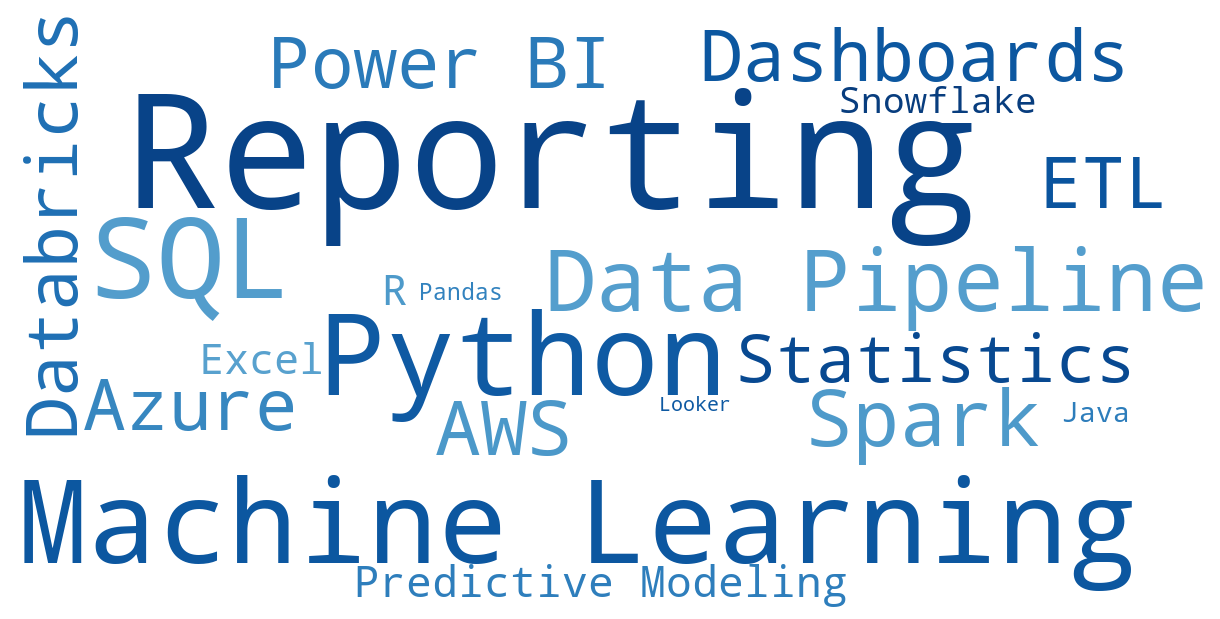

Saved → ..\outputs\figures\skills_wordcloud.png
Top 5 skills (frequency-weighted): [('Reporting', 93), ('Machine Learning', 43), ('Python', 41), ('SQL', 40), ('Data Pipeline', 29)]


In [4]:
# --- Cell: Skills wordcloud (Adzuna, frequency-weighted) ---
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from wordcloud import WordCloud

# Constants (re-declared for stand-alone runnability of this notebook)
ADZUNA_COLOR = '#1f77b4'
FIGURES_DIR = Path('../outputs/figures')
FIGURES_DIR.mkdir(exist_ok=True)

# --- Load skill frequencies ---
skills_df = pd.read_csv('../outputs/top_skills_overall.csv')
freq_dict = dict(zip(skills_df['skills'], skills_df['count']))

print(f"Building wordcloud from {len(freq_dict)} skills "
      f"(max count: {max(freq_dict.values())}, "
      f"min count: {min(freq_dict.values())})")

# --- Custom color function: monochrome blue, restricted to darker half ---
# Random within [0.55, 0.95] of the Blues colormap so all words stay
# readable on white background (light end of Blues would be invisible).
# Seeded on word hash so colors are stable across re-runs.
def blue_color_func(word, font_size, position, orientation,
                    random_state=None, **kwargs):
    rng = np.random.default_rng(hash(word) % (2**32))
    intensity = rng.uniform(0.55, 0.95)
    rgba = plt.cm.Blues(intensity)
    r, g, b = [int(c * 255) for c in rgba[:3]]
    return f'rgb({r}, {g}, {b})'

# --- Generate wordcloud ---
wc = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    max_words=50,
    color_func=blue_color_func,
    collocations=False,       # CRITICAL: preserves "Power BI", "Machine Learning" as single tokens
    prefer_horizontal=0.9,    # 10% vertical for visual variety
    relative_scaling=0.5,     # balance between rank and raw frequency
    random_state=42,          # reproducibility of layout
).generate_from_frequencies(freq_dict)

# --- Render ---
fig, ax = plt.subplots(figsize=(12, 6), dpi=100)
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
plt.tight_layout(pad=0)

# --- Save ---
wc_path = FIGURES_DIR / 'skills_wordcloud.png'
plt.savefig(wc_path, dpi=150, bbox_inches='tight', pad_inches=0.1)
plt.show()

print(f"Saved → {wc_path}")
print(f"Top 5 skills (frequency-weighted): "
      f"{list(freq_dict.items())[:5]}")

In [7]:
# --- Diag: structure of role x skill intersection ---

adz = pd.read_csv('../data/processed/adzuna_jobs_with_skills.csv')
print('Columns:', adz.columns.tolist())
print(f"Total row:{len(adz)}")
print(f"\nSalary disclosure: {adz['_salary_avg'].notna().sum() if '_salary_avg' in adz.columns else 'N/A'}")
print(f"\nRole distribution (top 10):")
print(adz['_role_label'].value_counts().head(10) if '_role_label' in adz.columns else "No _role_label column")

# Q1: How many rows have both salary disclosed and skills extracted?
adz['_salary_avg'] = (adz['salary_min'] + adz['salary_max']) / 2
print(f"Total rows: {len(adz)}")
print(f"Salary-disclosed: {adz['_salary_avg'].notna().sum()}")
print(f"Skills extracted: {adz['skills'].notna().sum()}")
print(f"Both (heatmap base): {(adz['_salary_avg'].notna() & adz['skills'].notna()).sum()}")

# Q2: Role proxy distribution (search_query as role label)
print(f"\nJobs per _search_query (with salary):")
print(adz[adz['_salary_avg'].notna()]['_search_query'].value_counts())

# Q3: Skills column format (string repr of list, or already list?)
print(f"\nSkills column sample (first non-null):")
print(repr(adz[adz['skills'].notna()]['skills'].iloc[0]))
print(f"Type: {type(adz[adz['skills'].notna()]['skills'].iloc[0])}")


Columns: ['salary_max', 'latitude', 'redirect_url', 'title', 'created', 'salary_min', 'id', 'description', 'longitude', 'contract_time', '_search_query', 'company', 'category', 'category_tag', 'location', 'location_area', 'contract_type', 'city', 'week', 'day_of_week', 'is_recent', 'skills', 'text_to_search']
Total row:1025

Salary disclosure: N/A

Role distribution (top 10):
No _role_label column
Total rows: 1025
Salary-disclosed: 258
Skills extracted: 1025
Both (heatmap base): 258

Jobs per _search_query (with salary):
_search_query
data analyst        68
business analyst    60
data engineer       47
data scientist      44
data consultant     35
BI analyst           4
Name: count, dtype: int64

Skills column sample (first non-null):
"['Dashboards']"
Type: <class 'str'>


In [9]:
# --- Cell: Parse skills column and explode to (job, skill) rows ---
import ast

# Base sample: jobs with BOTH salary disclosed AND skills extracted
base = adz[adz['_salary_avg'].notna() & adz['skills'].notna()].copy()

# Parse string-repr of list into actual Python list
# ast.literal_eval is safer than eval() — it only evaluates literals,
# never executes arbitrary code
base['_skills_parsed'] = base['skills'].apply(ast.literal_eval)

# Explode: one row per (job, skill) pair
# A job with 3 skills becomes 3 rows, each carrying the same salary + role
exploded = base.explode('_skills_parsed').rename(columns={'_skills_parsed': '_skill'})

# Drop empty-skills jobs (jobs whose skills list was [] would yield NaN after explode)
exploded = exploded[exploded['_skill'].notna()].copy()

print(f"Base jobs (salary + skills): {len(base)}")
print(f"After explode: {len(exploded)} (job, skill) pairs")
print(f"Avg skills per job: {len(exploded) / len(base):.1f}")
print(f"\nUnique skills in exploded set: {exploded['_skill'].nunique()}")
print(f"\nSample of exploded rows:")
print(exploded[['_search_query', '_skill', '_salary_avg']].head(8))

Base jobs (salary + skills): 258
After explode: 99 (job, skill) pairs
Avg skills per job: 0.4

Unique skills in exploded set: 23

Sample of exploded rows:
   _search_query      _skill  _salary_avg
0   data analyst  Dashboards      88832.0
2   data analyst  Dashboards     125000.0
2   data analyst   Reporting     125000.0
14  data analyst      Python      92497.0
14  data analyst         SQL      92497.0
14  data analyst       Excel      92497.0
14  data analyst  Statistics      92497.0
26  data analyst  Dashboards      97000.0


In [10]:
# --- Cell: Diagnose skills list length distribution ---
# Why: avg of 0.4 skills/job suggests most jobs have empty lists
# We need to know how many jobs have at least 1, 2, 3+ skills before building the heatmap

base['_n_skills'] = base['_skills_parsed'].apply(len)

print(f"Distribution of skills count per job (salary-disclosed sample, n={len(base)}):")
print(base['_n_skills'].value_counts().sort_index())
print(f"\nJobs with ≥1 skill: {(base['_n_skills'] >= 1).sum()}")
print(f"Jobs with ≥2 skills: {(base['_n_skills'] >= 2).sum()}")
print(f"Jobs with ≥3 skills: {(base['_n_skills'] >= 3).sum()}")
print(f"\nMean skills per job (among those with ≥1): "
      f"{base[base['_n_skills'] >= 1]['_n_skills'].mean():.2f}")

Distribution of skills count per job (salary-disclosed sample, n=258):
_n_skills
0    197
1     41
2     10
3      5
4      3
5      1
6      1
Name: count, dtype: int64

Jobs with ≥1 skill: 61
Jobs with ≥2 skills: 20
Jobs with ≥3 skills: 10

Mean skills per job (among those with ≥1): 1.62


In [12]:
# --- Cell: Setup assets/ folder for README ---
import shutil

# Source: analytical artifacts (Session 7 + 8)
FIGURES_DIR = Path('../outputs/figures')

# Destination: README-facing assets
ASSETS_DIR = Path('../assets')
ASSETS_DIR.mkdir(exist_ok=True)

# Files to copy (4 hero visuals for the README)
files_to_copy = [
    'skills_wordcloud.png',           # Session 8 — README banner
    'salary_by_role_boxplot.png',     # Session 7 hero chart #1
    'salary_by_region_barchart.png',  # Session 7 hero chart #2 (post-fix sous-titre)
    'salary_by_skill_barchart.png',   # Session 7 hero chart #3
]

# Copy each file
for fname in files_to_copy:
    src = FIGURES_DIR / fname
    dst = ASSETS_DIR / fname
    assert src.exists(), f"Missing source file: {src}"
    shutil.copy2(src, dst)             # copy2 preserves metadata (timestamps)
    print(f"  ✅ {fname}  →  assets/")

# Sanity check
assets_files = sorted(ASSETS_DIR.glob('*.png'))
print(f"\n📁 assets/ now contains {len(assets_files)} PNG files:")
for f in assets_files:
    size_kb = f.stat().st_size / 1024
    print(f"   {f.name}  ({size_kb:.0f} KB)")

  ✅ skills_wordcloud.png  →  assets/
  ✅ salary_by_role_boxplot.png  →  assets/
  ✅ salary_by_region_barchart.png  →  assets/
  ✅ salary_by_skill_barchart.png  →  assets/

📁 assets/ now contains 4 PNG files:
   salary_by_region_barchart.png  (150 KB)
   salary_by_role_boxplot.png  (141 KB)
   salary_by_skill_barchart.png  (83 KB)
   skills_wordcloud.png  (294 KB)
